# 2.5 Visualization of functional enrichment results (1)

Author: Xuezhu Sunny Wang

## Dataset 📊

- Summary table of differential genes (amyloid clones vs polyclones）


## Steps overview 📒
- Plot the results from functional enrichment with STRING (https://string-db.org/)


In [1]:
final_table<-read.csv(file='clonevsnormal_final_table.csv')

In [2]:
table(final_table$sample)


     ALHPC1plasma      ALHPC2plasma      ALHPC3plasma     ALk1preplasma 
               74               119               482              1431 
       ALk2plasma    ALk3postplasma     ALk3preplasma        ALk4plasma 
             4898               161              1399               998 
       ALk5plasma        ALk6plasma ALl10refracplasma ALl11refracplasma 
             1121              1121              3117               897 
      ALl12plasma       ALl13plasma       ALl14plasma       ALl15plasma 
              763               259              1176              5193 
      ALl16plasma       ALl18plasma       ALl19plasma     ALl1preplasma 
             1722               372              1808               878 
      ALl20plasma       ALl22plasma     ALl2preplasma       ALl30plasma 
              750               701               290               503 
    ALl3preplasma     ALl4preplasma    ALl5postplasma     ALl5preplasma 
             1642              1612              1

In [3]:
final_table<-final_table[which(final_table$sample!='ALN1plasma'),]

final_table_up<-final_table[which(final_table$avg_log2FC>0),]
gene_freq<-as.data.frame(table(final_table_up$gene))
write.csv(gene_freq,file='genefreq_up_ALonly.csv')

final_table_dw<-final_table[which(final_table$avg_log2FC<0),]
gene_freq<-as.data.frame(table(final_table_dw$gene))
write.csv(gene_freq,file='genefreq_dw_ALonly.csv')

In [4]:
importanceup<-read.csv(file='genefreq_up_ALonly.csv')
rownames(importanceup)<-importanceup$Var1
importanceup$Freq<-importanceup$Freq/40
importanceup<-importanceup[c('HLA-A','HLA-B','HLA-C',"ITM2B",'CST3','HLA-DOB','HLA-F',"CDKN1A","B2M","CCND1",'CD63','CD47','JUN','FOS',"JUND"),]

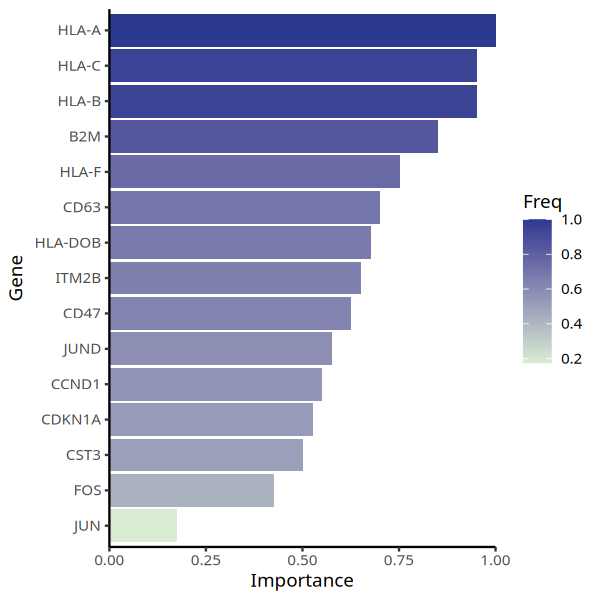

In [5]:
library("ggplot2")

options(repr.plot.height=5,repr.plot.width=5)
ggplot(importanceup,aes(x= reorder(Var1,Freq), y=Freq,fill=Freq)) +   
geom_bar(stat = "identity") +
coord_flip()+
scale_fill_gradient(low = "#d9ecd3", high = "#2c3991")+
xlab("Gene") +
scale_y_continuous(name="Importance",expand=c(0,0))+
theme_classic()

In [6]:
importancedw<-read.csv(file='genefreq_dw_ALonly.csv')
rownames(importancedw)<-importancedw$Var1
importancedw$Freq<-importancedw$Freq/40
importancedw<-importancedw[c("CD38",'CD81','CD74','CD19','CD44','CD99','CD79A','CD27','CD52','HLA-DPA1','HLA-DRB5','XBP1','TIMP1','HLA-DRB1','HLA-DMA','HLA-DQB1'),]

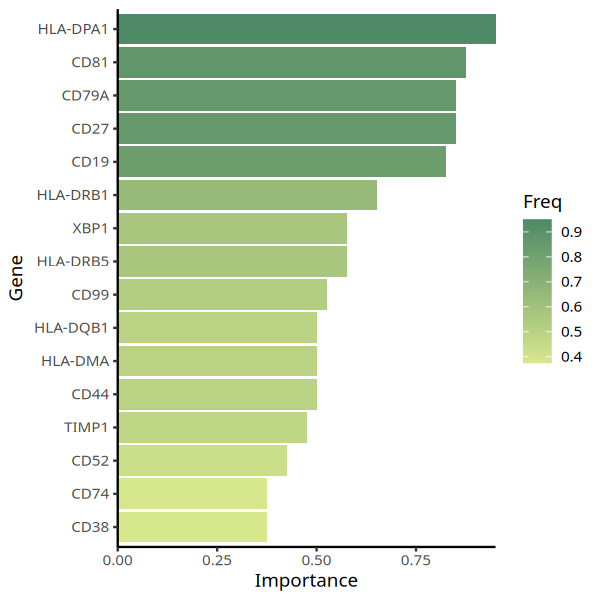

In [7]:
library("ggplot2")

options(repr.plot.height=5,repr.plot.width=5)
ggplot(importancedw,aes(x= reorder(Var1,Freq), y=Freq,fill=Freq)) +   
geom_bar(stat = "identity") +
coord_flip()+
scale_fill_gradient(low = "#d7e78c", high = "#4d8a65")+
xlab("Gene") +
scale_y_continuous(name="Importance",expand=c(0,0))+
theme_classic()

In [8]:
# Load packages
library(ggplot2)
library(readr)
library(dplyr)

# Read data
df <- read_tsv("enrichment.selected_up-ALonly.tsv")
df<-as.data.frame(df)
df<-df[,c(3,4,5,8,9)]
colnames(df)<-c('id','term','count','signal','FDR')
df$term<-paste(df$id,df$term,sep=':')



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Rows: 12 Columns: 11
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (6): #color, category, term ID, term description, matching proteins in y...
dbl (5): observed gene count, background gene count, strength, signal, false...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


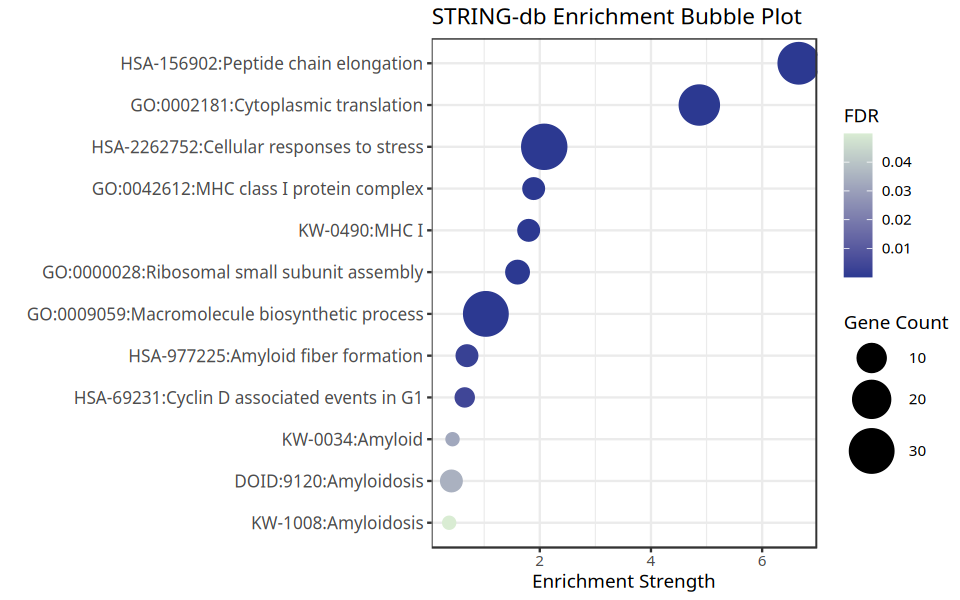

In [9]:
# Optional: keep top 20 enriched terms based on FDR
df_filtered <- df %>%
  arrange(FDR) %>%
  slice_head(n = 20)

options(repr.plot.height=5,repr.plot.width=8)
# Create the bubble plot
ggplot(df_filtered, aes(x = signal, y = reorder(term, signal))) +
  geom_point(aes(size = count, color = FDR)) +
  scale_color_gradient(high = "#d9ecd3",low = "#2c3991", name = "FDR") +
  scale_size(range = c(3, 12), name = "Gene Count") +
  theme_bw() +
  labs(
    x = "Enrichment Strength",
    y = "",
    title = "STRING-db Enrichment Bubble Plot"
  ) +
   theme(
    axis.text.y = element_text(size = 10),
    plot.margin = margin(t = 5, r = 5, b = 5, l = 20, unit = "pt")  # increase left margin
  )

In [10]:
p<-ggplot(df_filtered, aes(x = signal, y = reorder(term, signal))) +
  geom_point(aes(size = count, color = FDR)) +
  scale_color_gradient(high = "#d9ecd3",low = "#2c3991", name = "FDR") +
  scale_size(range = c(3, 12), name = "Gene Count") +
  theme_bw() +
  labs(
    x = "Enrichment Strength",
    y = "",
    title = "STRING-db Enrichment Bubble Plot"
  ) +
   theme(
    axis.text.y = element_text(size = 10),
    plot.margin = margin(t = 5, r = 5, b = 5, l = 20, unit = "pt")  # increase left margin
  )
ggsave("figure2c.pdf", plot = p, width = 7, height = 5)


In [11]:
# Load packages
library(ggplot2)
library(readr)
library(dplyr)

# Read data
df <- read_tsv("enrichment.selected_dw-ALonly.tsv")
df<-as.data.frame(df)
df<-df[,c(3,4,5,8,9)]
colnames(df)<-c('id','term','count','signal','FDR')
df$term<-paste(df$id,df$term,sep=':')


Rows: 11 Columns: 11
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (6): #color, category, term ID, term description, matching proteins in y...
dbl (5): observed gene count, background gene count, strength, signal, false...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


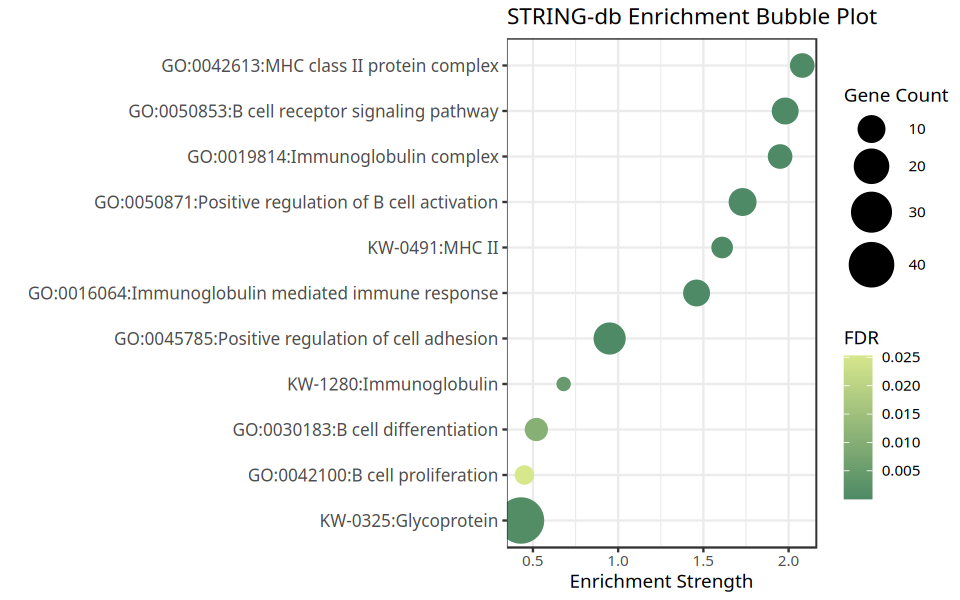

In [12]:
# Optional: keep top 20 enriched terms based on FDR
df_filtered <- df %>%
  arrange(FDR) %>%
  slice_head(n = 20)

options(repr.plot.height=5,repr.plot.width=8)
# Create the bubble plot
ggplot(df_filtered, aes(x = signal, y = reorder(term, signal))) +
  geom_point(aes(size = count, color = FDR)) +
  scale_color_gradient(high = "#d7e78c", low = "#4d8a65", name = "FDR") +
  scale_size(range = c(3, 12), name = "Gene Count") +
  theme_bw() +
  labs(
    x = "Enrichment Strength",
    y = "",
    title = "STRING-db Enrichment Bubble Plot"
  ) +
   theme(
    axis.text.y = element_text(size = 10),
    plot.margin = margin(t = 5, r = 5, b = 5, l = 30, unit = "pt")  # increase left margin
  )

In [13]:
p<-ggplot(df_filtered, aes(x = signal, y = reorder(term, signal))) +
  geom_point(aes(size = count, color = FDR)) +
  scale_color_gradient(high = "#d7e78c", low = "#4d8a65", name = "FDR") +
  scale_size(range = c(3, 12), name = "Gene Count") +
  theme_bw() +
  labs(
    x = "Enrichment Strength",
    y = "",
    title = "STRING-db Enrichment Bubble Plot"
  ) +
   theme(
    axis.text.y = element_text(size = 10),
    plot.margin = margin(t = 5, r = 5, b = 5, l = 30, unit = "pt")  # increase left margin
  )
ggsave("figure2c-2.pdf", plot = p, width = 8, height = 5)
